Mounting datasets from google drive  and unzipping it

In [10]:
from google.colab import drive
drive.mount('/content/drive')

# Create folders
!mkdir -p /content/data/images
!mkdir -p /content/data/labels

# Paths to your zip files
folder_path = '/content/drive/MyDrive/Capstone_Part1/vehicle_detection'
images_zip_path = f'{folder_path}/images.zip'
labels_zip_path = f'{folder_path}/labels.zip'

# Unzip into Colab
!unzip -q "$images_zip_path" -d /content/data/images
!unzip -q "$labels_zip_path" -d /content/data/labels

# Verify
import os
image_dir = '/content/data/images'
label_dir = '/content/data/labels'

print("First 5 images:", os.listdir(image_dir)[:5])
print("First 5 labels:", os.listdir(label_dir)[:5])


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
First 5 images: ['Images']
First 5 labels: ['labels.csv']


Flattening the image & label directory

In [11]:
!mv /content/data/images/Images/* /content/data/images
!rmdir /content/data/images/Images



In [12]:
print("First 5 images:", os.listdir('/content/data/images')[:5])


First 5 images: ['00000551.jpg', '00002353.jpg', '00004653.jpg', '00000148.jpg', '00000359.jpg']


In [13]:
!ls /content/data/labels
import pandas as pd

labels_path = '/content/data/labels/labels.csv'
df = pd.read_csv(labels_path)
print(df.head())



labels.csv
   00000000       pickup_truck  213   34  255   50
0         0                car  194   78  273  122
1         0                car  155   27  183   35
2         0  articulated_truck   43   25  109   55
3         0                car  106   32  124   45
4         1                bus  205  155  568  314



Generating YOLO Labels from Raw CSV with Error Handling and Logging


In [22]:
import pandas as pd
import os
import cv2
from glob import glob

# Paths
labels_csv_path = '/content/data/labels/labels.csv'
images_dir = '/content/data/images'
output_labels_dir = '/content/data/labels'

# Load CSV without headers
df = pd.read_csv(labels_csv_path, header=None)
df.columns = ['image_id', 'class', 'xmin', 'ymin', 'xmax', 'ymax']

# Generate class mapping
unique_classes = sorted(df['class'].unique())
class_map = {name: idx for idx, name in enumerate(unique_classes)}

# Save class mapping
with open('/content/classes.txt', 'w') as f:
    for name in unique_classes:
        f.write(f"{class_map[name]} = {name}\n")

print(f" Found {len(class_map)} classes. Saved to /content/classes.txt")

# Generate YOLO labels
count_success = 0
count_skipped = 0

for image_id in df['image_id'].unique():
    # Pad image ID to 8 digits
    image_filename = f"{int(image_id):08d}.jpg"
    image_path = os.path.join(images_dir, image_filename)
    txt_path = os.path.join(output_labels_dir, f"{int(image_id):08d}.txt")

    if not os.path.exists(image_path):
        count_skipped += 1
        continue

    img = cv2.imread(image_path)
    if img is None:
        count_skipped += 1
        continue

    h, w, _ = img.shape
    rows = df[df['image_id'] == image_id]

    with open(txt_path, 'w') as f:
        for _, row in rows.iterrows():
            class_id = class_map[row['class']]
            xmin, ymin, xmax, ymax = row['xmin'], row['ymin'], row['xmax'], row['ymax']
            x_center = ((xmin + xmax) / 2) / w
            y_center = ((ymin + ymax) / 2) / h
            width = (xmax - xmin) / w
            height = (ymax - ymin) / h
            f.write(f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}\n")

    count_success += 1

print(f" YOLO labels created for {count_success} images")
print(f" Skipped {count_skipped} images due to missing files or errors")


 Found 11 classes. Saved to /content/classes.txt
 YOLO labels created for 5626 images
 Skipped 104374 images due to missing files or errors


In [23]:
label_image_ids = set(df['image_id'].unique())
available_image_ids = set([int(os.path.splitext(f)[0]) for f in os.listdir(images_dir) if f.endswith('.jpg')])

missing = label_image_ids - available_image_ids
print(f" {len(missing)} label entries reference missing images.")
print("Example missing IDs:", list(missing)[:10])


 104374 label entries reference missing images.
Example missing IDs: [np.int64(5658), np.int64(5659), np.int64(5660), np.int64(5661), np.int64(5662), np.int64(5663), np.int64(5664), np.int64(5665), np.int64(5666), np.int64(5667)]


In [25]:
import pandas as pd
import os

# Read CSV and assign column names
df = pd.read_csv('/content/data/labels/labels.csv', header=None)
df.columns = ['image_id', 'class', 'xmin', 'ymin', 'xmax', 'ymax']

# List of available image files
available_images = os.listdir('/content/data/images')

# Extract image_ids from available image filenames
available_ids = [int(f.split('.')[0]) for f in available_images if f.lower().endswith('.jpg')]
available_ids_set = set(available_ids)

# Filter labels only for images you actually have
df_filtered = df[df['image_id'].isin(available_ids_set)]
print(f" Filtered labels from {len(df)} to {len(df_filtered)} rows matching available images.")

# Save filtered labels to use in YOLO conversion
df_filtered.to_csv('/content/data/labels/filtered_labels.csv', index=False, header=False)


 Filtered labels from 351549 to 17967 rows matching available images.


Generating YOLO .txt Labels Using the Filtered CSV

In [26]:
import pandas as pd
import os
import cv2

# Paths
labels_csv_path = '/content/data/labels/filtered_labels.csv'
images_dir = '/content/data/images'
output_labels_dir = '/content/data/labels'

# Read filtered CSV
df = pd.read_csv(labels_csv_path, header=None)
df.columns = ['image_id', 'class', 'xmin', 'ymin', 'xmax', 'ymax']

# Class mapping (auto-generated)
unique_classes = sorted(df['class'].unique())
class_map = {name: idx for idx, name in enumerate(unique_classes)}

# Save class mapping
with open('/content/classes.txt', 'w') as f:
    for name in unique_classes:
        f.write(f"{class_map[name]} = {name}\n")

print(f" Found {len(class_map)} unique classes. Mapping saved to /content/classes.txt")

# Generate YOLO .txt files
count_success = 0
for image_id in df['image_id'].unique():
    image_filename = f"{int(image_id):08d}.jpg"
    image_path = os.path.join(images_dir, image_filename)
    txt_path = os.path.join(output_labels_dir, f"{int(image_id):08d}.txt")

    if not os.path.exists(image_path):
        continue

    img = cv2.imread(image_path)
    if img is None:
        continue
    h, w, _ = img.shape

    rows = df[df['image_id'] == image_id]
    with open(txt_path, 'w') as f:
        for _, row in rows.iterrows():
            class_id = class_map[row['class']]
            xmin, ymin, xmax, ymax = row['xmin'], row['ymin'], row['xmax'], row['ymax']
            x_center = ((xmin + xmax) / 2) / w
            y_center = ((ymin + ymax) / 2) / h
            width = (xmax - xmin) / w
            height = (ymax - ymin) / h
            f.write(f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}\n")
    count_success += 1

print(f" YOLO label files generated for {count_success} images.")


 Found 11 unique classes. Mapping saved to /content/classes.txt
 YOLO label files generated for 5626 images.


Splitting into Train/Val Folders (YOLO Format)

In [27]:
import os
import random
import shutil

# Paths
images_dir = '/content/data/images'
labels_dir = '/content/data/labels'
base_dir = '/content/yolo_dataset'

# Create folder structure
os.makedirs(f'{base_dir}/images/train', exist_ok=True)
os.makedirs(f'{base_dir}/images/val', exist_ok=True)
os.makedirs(f'{base_dir}/labels/train', exist_ok=True)
os.makedirs(f'{base_dir}/labels/val', exist_ok=True)

# Get only labeled images (match label file exists)
image_files = [f for f in os.listdir(images_dir) if f.endswith('.jpg')]
labeled_images = [f for f in image_files if os.path.exists(os.path.join(labels_dir, f.replace('.jpg', '.txt')))]

# Shuffle and split
random.shuffle(labeled_images)
split_idx = int(0.8 * len(labeled_images))
train_images = labeled_images[:split_idx]
val_images = labeled_images[split_idx:]

def move_files(file_list, split):
    for img in file_list:
        label = img.replace('.jpg', '.txt')
        shutil.copy2(os.path.join(images_dir, img), f'{base_dir}/images/{split}/{img}')
        shutil.copy2(os.path.join(labels_dir, label), f'{base_dir}/labels/{split}/{label}')

move_files(train_images, 'train')
move_files(val_images, 'val')

print(f" Split complete: {len(train_images)} training / {len(val_images)} validation images")


 Split complete: 4500 training / 1126 validation images


Creating vehicle.yaml file


In [28]:
# Read class names from classes.txt
with open('/content/classes.txt', 'r') as f:
    class_lines = f.readlines()
class_names = [line.strip().split(' = ')[1] for line in class_lines]

yaml_content = f"""
train: /content/yolo_dataset/images/train
val: /content/yolo_dataset/images/val

nc: {len(class_names)}
names: {class_names}
"""

with open('/content/vehicle.yaml', 'w') as f:
    f.write(yaml_content)

print(" YOLOv5 dataset config created at /content/vehicle.yaml")


 YOLOv5 dataset config created at /content/vehicle.yaml


Clone YOLOv5 & Installing it's Dependencies

In [29]:
# Clone YOLOv5 repo
!git clone https://github.com/ultralytics/yolov5

# Go into the directory
%cd yolov5

# Install dependencies
!pip install -r requirements.txt


Cloning into 'yolov5'...
remote: Enumerating objects: 17533, done.
remote: Counting objects: 100% (35/35), done.
remote: Compressing objects: 100% (35/35), done.
remote: Total 17533 (delta 15), reused 1 (delta 0), pack-reused 17498 (from 4)
Receiving objects: 100% (17533/17533), 16.63 MiB | 22.77 MiB/s, done.
Resolving deltas: 100% (12011/12011), done.
/content/yolov5
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 88.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 73.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 40.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 834.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s et

Training on the training dataset with Yolo5s.pt

In [30]:
!python train.py --img 640 --batch 16 --epochs 50 --data /content/vehicle.yaml --weights yolov5s.pt --cache



Streaming output truncated to the last 5000 lines.
  with torch.cuda.amp.autocast(amp):
      41/49      3.98G    0.02312    0.01648   0.006714         92        640:  25% 71/282 [00:21<01:27,  2.40it/s]/content/yolov5/train.py:414: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(amp):
      41/49      3.98G    0.02314    0.01644   0.006717         61        640:  26% 72/282 [00:22<01:21,  2.56it/s]/content/yolov5/train.py:414: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(amp):
      41/49      3.98G    0.02316    0.01646   0.006724         99        640:  26% 73/282 [00:22<01:19,  2.62it/s]/content/yolov5/train.py:414: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(amp

Running Inference on Validation Set

In [31]:
!python detect.py --weights runs/train/exp/weights/best.pt --img 640 --conf 0.25 --source /content/yolo_dataset/images/val



detect: weights=['runs/train/exp/weights/best.pt'], source=/content/yolo_dataset/images/val, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-425-g85acef3a Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)

Fusing layers... 
Model summary: 157 layers, 7039792 parameters, 0 gradients, 15.8 GFLOPs
image 1/1126 /content/yolo_dataset/images/val/00000001.jpg: 448x640 2 buss, 2 cars, 3 single_unit_trucks, 29.9ms
image 2/1126 /content/yolo_dataset/images/val/00000005.jpg: 448x640 1 articulated_truck, 1 car, 9.0ms
image 3/1126 /content/yolo_dataset/images/val/00000009.jpg: 448x640 7 cars, 9.0ms
imag

Visualize Detection Results

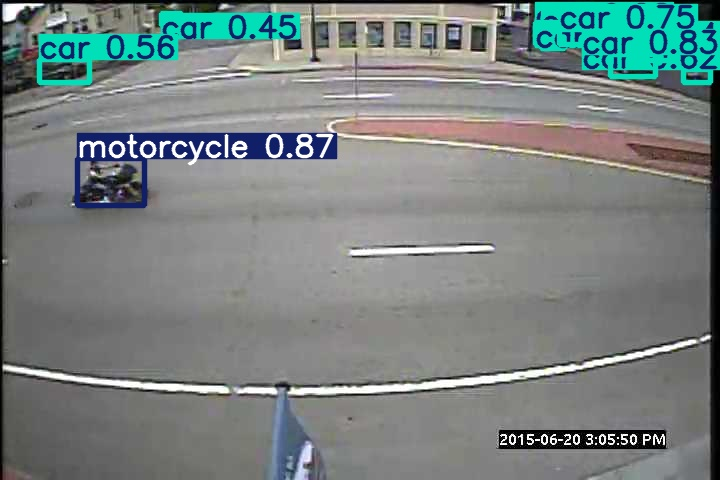

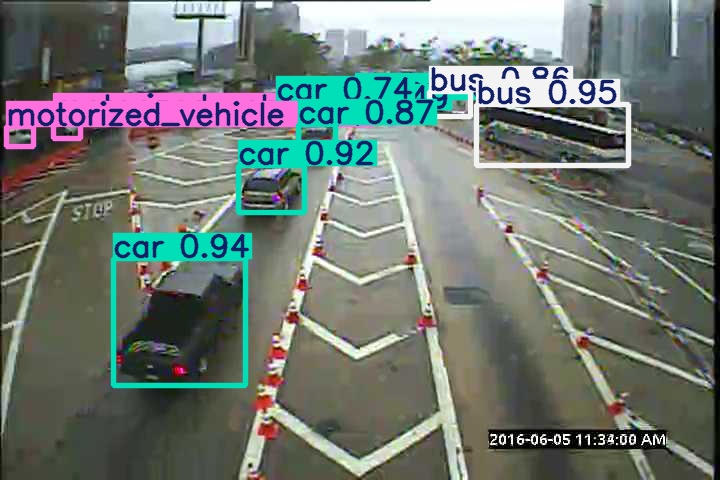

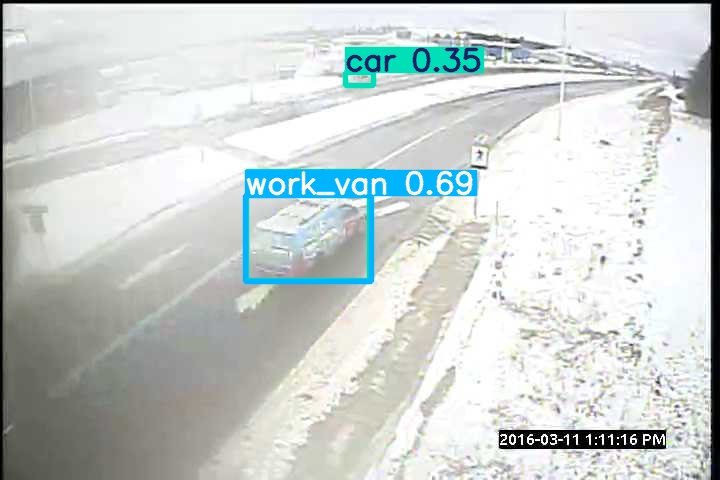

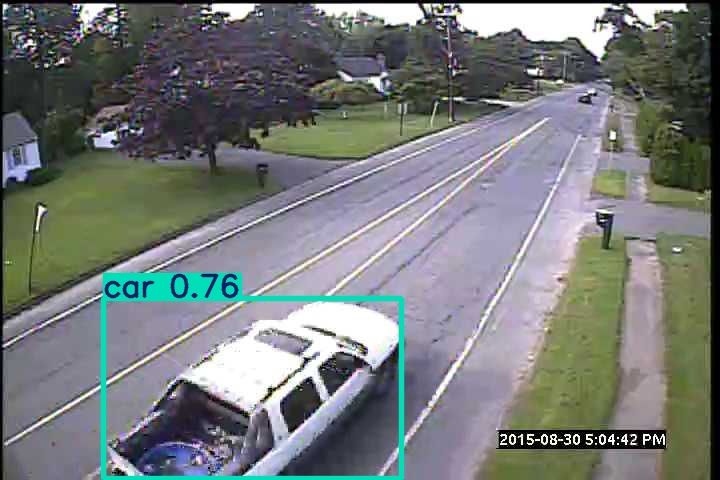

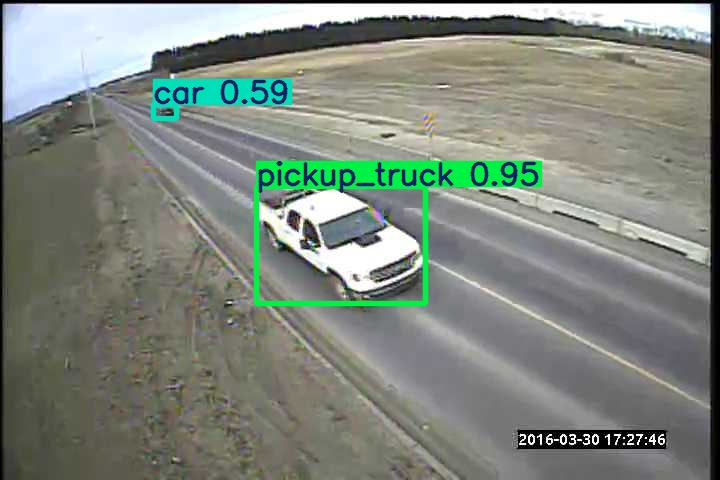

In [33]:
import glob
from IPython.display import Image, display

result_imgs = glob.glob('runs/detect/exp/*.jpg')  # adjust exp if needed
for img_path in result_imgs[:5]:  # view first 5 results
    display(Image(filename=img_path))


To save the trained model to Drive:

In [34]:
!cp runs/train/exp/weights/best.pt /content/drive/MyDrive/vehicle_detection/


cp: cannot create regular file '/content/drive/MyDrive/vehicle_detection/': Not a directory


To save detected images:


In [35]:
!cp -r runs/detect/exp /content/drive/MyDrive/vehicle_detection/inference_outputs/


cp: cannot create directory '/content/drive/MyDrive/vehicle_detection/inference_outputs/': No such file or directory


In [36]:
# 🚀 Save all essential Part 1 outputs to Google Drive

# Define paths
drive_base = '/content/drive/MyDrive/Capstone_Part1'
labels_dir = f'{drive_base}/yolo_labels'

# Create folders
!mkdir -p "{drive_base}"
!mkdir -p "{labels_dir}"

# Copy files
!cp /content/vehicle.yaml "{drive_base}/vehicle.yaml"
!cp /content/classes.txt "{drive_base}/classes.txt"
!cp /content/data/labels/*.txt "{labels_dir}/"

# Auto-detect most recent results folder (exp, exp2, etc.)
import os, shutil
train_dir = '/content/runs/train'
if os.path.exists(train_dir):
    exps = sorted(os.listdir(train_dir), key=lambda x: os.path.getmtime(os.path.join(train_dir, x)))
    latest_exp = exps[-1]
    results_src = os.path.join(train_dir, latest_exp, 'results.png')
    results_dst = os.path.join(drive_base, 'results.png')
    if os.path.exists(results_src):
        shutil.copy(results_src, results_dst)
        print(f" Copied results.png from {latest_exp}")
    else:
        print(" results.png not found in latest run.")
else:
    print(" No training runs found.")

print(" All key Part 1 files are now saved in your Drive!")


 No training runs found.
 All key Part 1 files are now saved in your Drive!
